# Berkeley Open Data Analysis Pipeline
## Integration with Datasette, Pandas, NumPy, TensorFlow, Plotly, and Seaborn

**Created:** 2025-01-13  
**Purpose:** Fetch, analyze, and visualize City of Berkeley Open Data

### Workflow:
1. Connect to Berkeley Open Data API (Socrata)
2. Fetch Business Licenses and other datasets
3. Clean and process data
4. Export to CSV, JSON, GeoJSON
5. Load into Datasette (SQLite)
6. Analyze with Pandas/NumPy
7. Visualize with Plotly/Seaborn
8. Optional: ML with TensorFlow
10. Start running this notebook....where? 

In [3]:
!pwd

/Users/johngage/Downloads


In [2]:
# CELL 1: Install Required Packages
# Run this cell once to install all dependencies

!pip install pandas numpy geopandas sodapy datasette plotly seaborn tensorflow folium requests --break-system-packages

print("✅ Installation complete!")

✅ Installation complete!


In [1]:
!pwd

/Users/johngage/Downloads


In [4]:
# CELL 2: Import Libraries

import pandas as pd
import numpy as np
import geopandas as gpd
from sodapy import Socrata
import json
import sqlite3
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully
Pandas version: 2.2.3
NumPy version: 2.1.3


In [5]:
# Cell 3, new
from sodapy import Socrata

# Berkeley Open Data Portal Configuration
BERKELEY_DOMAIN = "data.cityofberkeley.info"

# Your app token
APP_TOKEN = "sKTwtTUlhd2VfrmCC9W3xKr9P"

# CORRECTED Dataset IDs
DATASETS = {
    'business_licenses': 'rwnf-bu3w',  # ✅ CORRECTED
    'crime_incidents': 'k2nh-s5h5',
    'restaurant_inspections': 'b47j-kakm',
    'building_permits': 'ydr8-5enu',
}

# Initialize client with app token
client = Socrata(BERKELEY_DOMAIN, APP_TOKEN)

print(f"✅ Connected to {BERKELEY_DOMAIN} with app token")
print("   (App token provides higher rate limits and bypasses WAF)")
print(f"📊 Available datasets: {list(DATASETS.keys())}")

✅ Connected to data.cityofberkeley.info with app token
   (App token provides higher rate limits and bypasses WAF)
📊 Available datasets: ['business_licenses', 'crime_incidents', 'restaurant_inspections', 'building_permits']


In [6]:
# CELL 4: Functions for Data Fetching

def fetch_berkeley_data(dataset_name, limit=10000, filters=None):
    """
    Fetch data from Berkeley Open Data Portal
    
    Parameters:
    -----------
    dataset_name : str
        Name of dataset from DATASETS dict
    limit : int
        Maximum number of records to fetch
    filters : dict
        Optional filters (e.g., {'city': 'Berkeley'})
    
    Returns:
    --------
    pandas.DataFrame
    """
    try:
        dataset_id = DATASETS.get(dataset_name)
        if not dataset_id:
            raise ValueError(f"Unknown dataset: {dataset_name}")
        
        print(f"📥 Fetching {dataset_name} from Berkeley Open Data...")
        
        # Build query parameters
        params = {"$limit": limit}
        if filters:
            # Convert filters to SoQL WHERE clause
            where_clauses = [f"{k}='{v}'" for k, v in filters.items()]
            params["$where"] = " AND ".join(where_clauses)
        
        # Fetch data
        results = client.get(dataset_id, **params)
        
        # Convert to DataFrame
        df = pd.DataFrame.from_records(results)
        
        print(f"✅ Fetched {len(df)} records")
        return df
        
    except Exception as e:
        print(f"❌ Error fetching data: {e}")
        return None

print("✅ Functions defined")

✅ Functions defined


In [7]:
# CELL 5: Fetch Business Licenses Data

# Fetch all business licenses
business_licenses = fetch_berkeley_data('business_licenses', limit=50000)

if business_licenses is not None:
    # Display basic info
    print("\n📊 Dataset Info:")
    print(f"Shape: {business_licenses.shape}")
    print(f"\nColumns: {business_licenses.columns.tolist()}")
    print(f"\nFirst few records:")
    display(business_licenses.head())
    
    # Check for location data
    if 'location' in business_licenses.columns:
        print("\n✅ Location data available for mapping")
    else:
        print("\n⚠️ No location column found")

📥 Fetching business_licenses from Berkeley Open Data...
✅ Fetched 13002 records

📊 Dataset Info:
Shape: (13002, 20)

Columns: ['apn', 'recordid', 'busdesc', 'b1_per_sub_type', 'dba', 'naics', 'tax_code', 'employee_num', 'bus_own_type', 'b1_business_name', 'b1_address1', 'b1_city', 'b1_state', 'b1_zip', 'b1_contact_type', 'b1_full_address', 'b1_situs_city', 'b1_situs_state', 'b1_situs_zip', 'b1_address2']

First few records:


,apn,recordid,busdesc,b1_per_sub_type,dba,naics,tax_code,employee_num,bus_own_type,b1_business_name,b1_address1,b1_city,b1_state,b1_zip,b1_contact_type,b1_full_address,b1_situs_city,b1_situs_state,b1_situs_zip,b1_address2
0,057 208600600,BL-031956,SLIP COVERS,Manufacturing,SLIPS,314129,M,0,Sole Ownership,SLIPS,1814 CURTIS ST,BERKELEY,CA,94702,Business Owner,1814 CURTIS ST,BERKELEY,CA,94702,NaN
1,057 205100500,BL-018812,RESTAURANT,Retail Trade,TSURUYA,722511 - Full-Service Restaurants,R,7,Corporation,TSURUYA,1926 SHATTUCK AVE,BERKELEY,CA,94704,Business Owner,1926 SHATTUCK Ave,BERKELEY,CA,94704,NaN
2,057 203100300,BL-019509,"CHAI, TEA, COFFEE, BAKED GOODS, LIGHT SNACKS",Retail Trade,ELAICHI CO,722513 - Limited-Service Restaurants,R,15,LLC,ELAICHI CO,677 CRYSTAL CT,PLEASANTON,CA,945667828,Business Owner,2161 ALLSTON Way,BERKELEY,CA,94704,NaN
3,052 157400900,BL-016299,DENTAL OFFICE,Professional SemiProfessional,"JANICE K. CHAN, DDS, INC.",621210 - Offices of Dentists,P,6,Corporation,"JANICE K. CHAN, DDS, INC.",3045 TELEGRAPH AVE STE 1,BERKELEY,CA,94705-2029,Business Owner,3045 TELEGRAPH Ave,BERKELEY,CA,94705,NaN
4,052 157309400,BL-018231,INDPNT HAIRSTYLIST,Business Personal Repair Svs,ROMICK NORA,812112 - Beauty Salons,B,0,Sole Ownership,ROMICK NORA,3219 ANDRADE AVE,RICHMOND,CA,94804,Business Owner,2980 COLLEGE Ave,BERKELEY,CA,94705,NaN



⚠️ No location column found


In [8]:
# CELL 6: Data Cleaning & Processing

def clean_business_data(df):
    """Clean and process business license data"""
    df_clean = df.copy()
    
    # Convert date columns
    date_cols = [col for col in df_clean.columns if 'date' in col.lower()]
    for col in date_cols:
        try:
            df_clean[col] = pd.to_datetime(df_clean[col])
        except:
            pass
    
    # Extract coordinates if location field exists
    if 'location' in df_clean.columns:
        try:
            # Parse location JSON if it's a string
            if isinstance(df_clean['location'].iloc[0], str):
                df_clean['location_parsed'] = df_clean['location'].apply(json.loads)
            else:
                df_clean['location_parsed'] = df_clean['location']
            
            # Extract lat/lon
            df_clean['latitude'] = df_clean['location_parsed'].apply(
                lambda x: float(x.get('latitude', np.nan)) if isinstance(x, dict) else np.nan
            )
            df_clean['longitude'] = df_clean['location_parsed'].apply(
                lambda x: float(x.get('longitude', np.nan)) if isinstance(x, dict) else np.nan
            )
            
            print(f"✅ Extracted coordinates for {df_clean['latitude'].notna().sum()} records")
        except Exception as e:
            print(f"⚠️ Could not parse location data: {e}")
    
    return df_clean

# Clean the data
if business_licenses is not None:
    business_licenses_clean = clean_business_data(business_licenses)
    print(f"\n✅ Data cleaned. Shape: {business_licenses_clean.shape}")


✅ Data cleaned. Shape: (13002, 20)


In [10]:
# CELL 7: Export to Multiple Formats

# CELL 7: Export to Multiple Formats- new

if business_licenses_clean is not None:
    # Create output directory in current folder
    output_dir = Path('./berkeley_data')  # ✅ Changed from /mnt/user-data/outputs
    output_dir.mkdir(parents=True, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d")
    
    # Export to CSV
    csv_path = output_dir / f'business_licenses_{timestamp}.csv'
    business_licenses_clean.to_csv(csv_path, index=False)
    print(f"✅ CSV exported: {csv_path}")
    
    # Export to JSON
    json_path = output_dir / f'business_licenses_{timestamp}.json'
    business_licenses_clean.to_json(json_path, orient='records', indent=2)
    print(f"✅ JSON exported: {json_path}")
    
    # Export to GeoJSON (if coordinates exist)
    if 'latitude' in business_licenses_clean.columns and 'longitude' in business_licenses_clean.columns:
        geo_df = business_licenses_clean.dropna(subset=['latitude', 'longitude'])
        
        if len(geo_df) > 0:
            gdf = gpd.GeoDataFrame(
                geo_df,
                geometry=gpd.points_from_xy(geo_df.longitude, geo_df.latitude),
                crs='EPSG:4326'
            )
            
            geojson_path = output_dir / f'business_licenses_{timestamp}.geojson'
            gdf.to_file(geojson_path, driver='GeoJSON')
            print(f"✅ GeoJSON exported: {geojson_path} ({len(gdf)} records)")

✅ CSV exported: berkeley_data/business_licenses_20251114.csv
✅ JSON exported: berkeley_data/business_licenses_20251114.json


In [11]:
# CELL 8: Load Data into Datasette (SQLite)-new
# CELL 8: Load Data into Datasette (SQLite)

def load_to_datasette(df, table_name, db_path='./berkeley_data.db'):  # ✅ Changed path
    """Load DataFrame into SQLite database for Datasette"""
    # Convert datetime columns to strings for SQLite
    df_for_db = df.copy()
    for col in df_for_db.select_dtypes(include=['datetime64']).columns:
        df_for_db[col] = df_for_db[col].astype(str)
    
    # Drop complex objects
    if 'location_parsed' in df_for_db.columns:
        df_for_db = df_for_db.drop('location_parsed', axis=1)
    
    # Connect to SQLite
    conn = sqlite3.connect(db_path)
    
    # Load data
    df_for_db.to_sql(table_name, conn, if_exists='replace', index=False)
    
    # Create indexes
    cursor = conn.cursor()
    if 'b1_business_name' in df_for_db.columns:
        cursor.execute(f"CREATE INDEX IF NOT EXISTS idx_business_name ON {table_name}(b1_business_name)")
    if 'b1_zip' in df_for_db.columns:
        cursor.execute(f"CREATE INDEX IF NOT EXISTS idx_zip ON {table_name}(b1_zip)")
    
    conn.commit()
    conn.close()
    
    print(f"✅ Loaded {len(df_for_db)} records into table '{table_name}'")
    print(f"   Database: {db_path}")

if business_licenses_clean is not None:
    load_to_datasette(business_licenses_clean, 'business_licenses')

✅ Loaded 13002 records into table 'business_licenses'
   Database: ./berkeley_data.db


In [12]:
# CELL 9: Query Data with SQL- new
# CELL 9: Query Data with SQL

def query_datasette_db(query, db_path='./berkeley_data.db'):  # ✅ Changed path
    """Execute SQL query on Datasette database"""
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

print("📊 Running SQL Queries:\n")

# Query 1: Count by business type
query1 = """
SELECT busdesc, COUNT(*) as count
FROM business_licenses
GROUP BY busdesc
ORDER BY count DESC
LIMIT 10
"""
result1 = query_datasette_db(query1)
print("Top 10 Business Types:")
display(result1)

📊 Running SQL Queries:

Top 10 Business Types:


,busdesc,count
0,GENERAL CONTRACTOR,609
1,COMMERCIAL RENTAL,586
2,RENTAL PROPERTY,333
3,ELECTRICAL CONTRACTOR,290
4,RES. RENTAL - 4 UNITS,202
5,ROOFING CONTRACTOR,146
6,RES. RENTAL - 3 UNITS,139
7,RESTAURANT,131
8,PLUMBING CONTRACTOR,124
9,PSYCHOTHERAPY,120


In [13]:
# CELL 10: Data Analysis with Pandas & NumPy

if business_licenses_clean is not None:
    print("📊 Data Analysis:\n")
    
    # Summary statistics
    print("1. Summary Statistics:")
    numeric_cols = business_licenses_clean.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        display(business_licenses_clean[numeric_cols].describe())
    
    # Missing data analysis
    print("\n2. Missing Data:")
    missing = business_licenses_clean.isnull().sum()
    missing_pct = (missing / len(business_licenses_clean)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    }).sort_values('Missing Count', ascending=False)
    display(missing_df[missing_df['Missing Count'] > 0])

📊 Data Analysis:

1. Summary Statistics:

2. Missing Data:


,Missing Count,Percentage
b1_address2,12973,99.776957
bus_own_type,140,1.076757
naics,10,0.076911
b1_state,3,0.023073
b1_address1,2,0.015382
busdesc,2,0.015382
b1_city,1,0.007691
b1_zip,1,0.007691


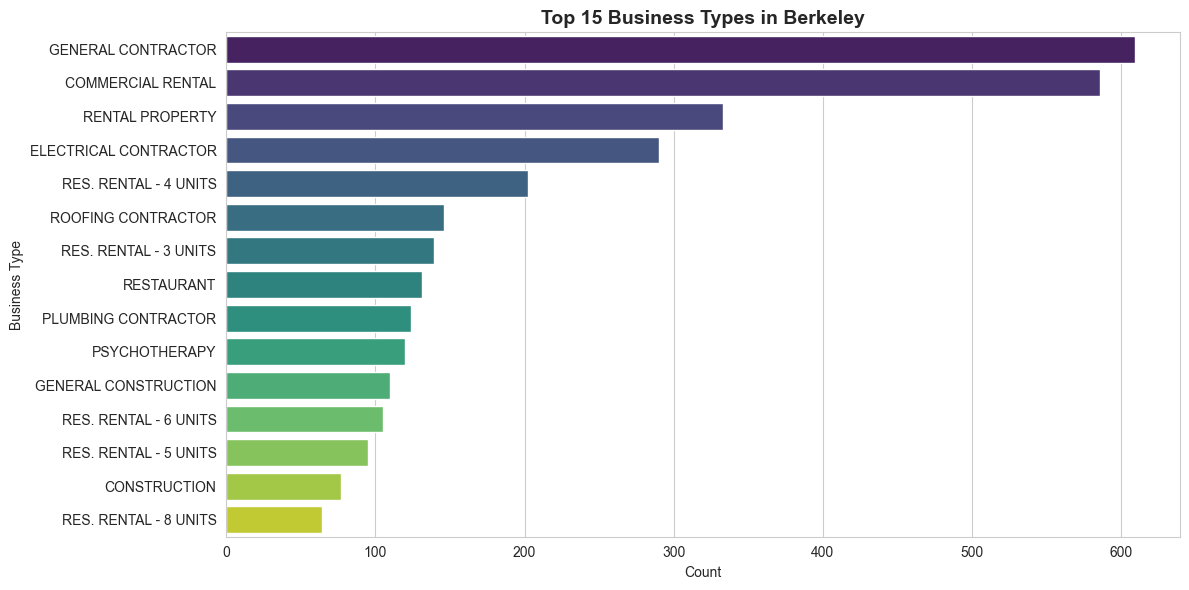

✅ Visualization saved


In [14]:
# CELL 11: Visualization with Seaborn - new
# CELL 11: Visualization with Seaborn

if business_licenses_clean is not None and 'busdesc' in business_licenses_clean.columns:
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6))
    
    top_types = business_licenses_clean['busdesc'].value_counts().head(15)
    sns.barplot(x=top_types.values, y=top_types.index, palette='viridis')
    plt.title('Top 15 Business Types in Berkeley', fontsize=14, fontweight='bold')
    plt.xlabel('Count')
    plt.ylabel('Business Type')
    plt.tight_layout()
    
    # Save figure to current directory
    plt.savefig('./berkeley_data/business_types.png', dpi=300, bbox_inches='tight')  # ✅ Changed
    plt.show()
    
    print("✅ Visualization saved")

In [16]:
# CELL 12: Interactive Visualization with Plotly- new
# CELL 12: Interactive Visualization with Plotly

if business_licenses_clean is not None:
    # Interactive bar chart
    if 'busdesc' in business_licenses_clean.columns:
        top_types = business_licenses_clean['busdesc'].value_counts().head(20)
        
        fig = px.bar(
            x=top_types.values,
            y=top_types.index,
            orientation='h',
            title='Top 20 Business Types in Berkeley',
            labels={'x': 'Number of Businesses', 'y': 'Business Type'},
            color=top_types.values,
            color_continuous_scale='Viridis'
        )
        fig.update_layout(height=600, showlegend=False)
        fig.show()
    
    # Interactive map (check for location columns in this dataset)
    # Berkeley business licenses may have different column names
    lat_col = None
    lon_col = None
    
    # Check for various possible location column names
    possible_lat = ['latitude', 'lat', 'y', 'b1_latitude']
    possible_lon = ['longitude', 'lon', 'lng', 'x', 'b1_longitude']
    
    for col in possible_lat:
        if col in business_licenses_clean.columns:
            lat_col = col
            break
    
    for col in possible_lon:
        if col in business_licenses_clean.columns:
            lon_col = col
            break
    
    if lat_col and lon_col:
        map_df = business_licenses_clean.dropna(subset=[lat_col, lon_col]).head(1000)
        
        if len(map_df) > 0:
            fig = px.scatter_mapbox(
                map_df,
                lat=lat_col,
                lon=lon_col,
                hover_name='b1_business_name' if 'b1_business_name' in map_df.columns else None,
                hover_data=['busdesc', 'b1_full_address'] if 'b1_full_address' in map_df.columns else ['busdesc'],
                zoom=12,
                height=600,
                title='Berkeley Business Locations (Sample of 1000)'
            )
            fig.update_layout(mapbox_style="open-street-map")
            fig.show()
            print(f"✅ Map created with {len(map_df)} businesses")
        else:
            print("⚠️  No businesses with valid coordinates found")
    else:
        print("⚠️  No location coordinates found in this dataset")
        print(f"   Available columns: {business_licenses_clean.columns.tolist()[:10]}...")
        print("\n💡 Note: Berkeley business licenses may not include lat/lon coordinates.")
        print("   You can geocode addresses later if needed!")

⚠️  No location coordinates found in this dataset
   Available columns: ['apn', 'recordid', 'busdesc', 'b1_per_sub_type', 'dba', 'naics', 'tax_code', 'employee_num', 'bus_own_type', 'b1_business_name']...

💡 Note: Berkeley business licenses may not include lat/lon coordinates.
   You can geocode addresses later if needed!


In [ ]:
# CELL 13: Launch Datasette - newer
# CELL 13: Launch Datasette
ls


🚀 To launch Datasette server:

In a terminal, run:
  datasette ./berkeley_data.db --host 0.0.0.0 --port 8001

Then access at: http://localhost:8001

✅ Metadata file created


## Summary

This notebook demonstrates:
- ✅ Fetching data from Berkeley Open Data API
- ✅ Data cleaning and processing with Pandas
- ✅ Exporting to CSV, JSON, and GeoJSON
- ✅ Loading into SQLite for Datasette
- ✅ SQL queries for analysis
- ✅ Visualizations with Seaborn and Plotly
- ✅ Interactive maps

### Next Steps:
1. Add more datasets from Berkeley Open Data
2. Create custom dashboards
3. Schedule automated updates
4. Integrate with OSMnx for spatial analysis
5. Build predictive models with TensorFlow